In [1]:
#Imports
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [2]:
#Load data 
df = sns.load_dataset('titanic')

# 1. Data exploration


In [3]:
# Basic Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


#### Now this is the tables and which have null values, the embarked column is almost completely full, age is missing around a quarter , and deck has around only a quarter of entries with the rest of null.

In [4]:
df.describe(include='all')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Above is the statisitcs of the numerical and continuous data, such as Q1, Q2, Q3. We can also notice that magnitudes of the features are not scaled the same. 

In [5]:
# Paassenger class 
df['pclass'].value_counts()

pclass
3    491
1    216
2    184
Name: count, dtype: int64

#### Passenger Class a majority being class 3. Look at the visualization below for better comprehension.

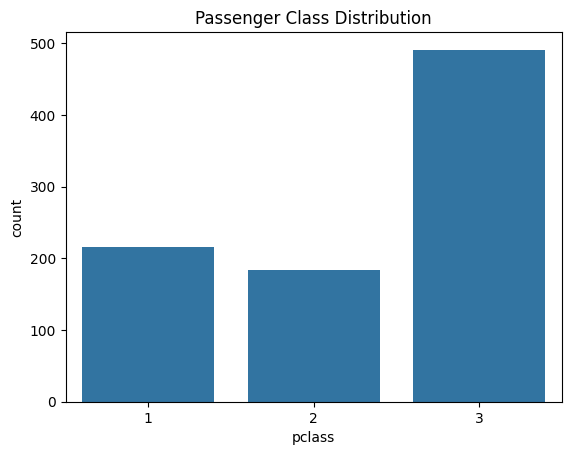

In [6]:
# Passenger class distribution
sns.countplot(x='pclass', data=df)
plt.title('Passenger Class Distribution')
plt.show()


In [7]:
# Survived Class
df['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

#### Survived Class illustrates that 549 of 891 (61.6%) did not survive based on the raw data.

In [8]:
# Sex distribution 
df['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

#### In terms of Sex, 577 of the 891 are male (64%), illustrating a majority were male passengers from the survey

In [9]:
# Survived By class
pd.crosstab(df['pclass'], df['survived'], margins=True)

survived,0,1,All
pclass,,,
1,80,136,216
2,97,87,184
3,372,119,491
All,549,342,891


#### As we can see here, class 1 majority survived (62.9%), class 2 a little less than half survived (47.2%), and in class 3 a minority survived (24.2%) around a quarter. Look at the viualization below

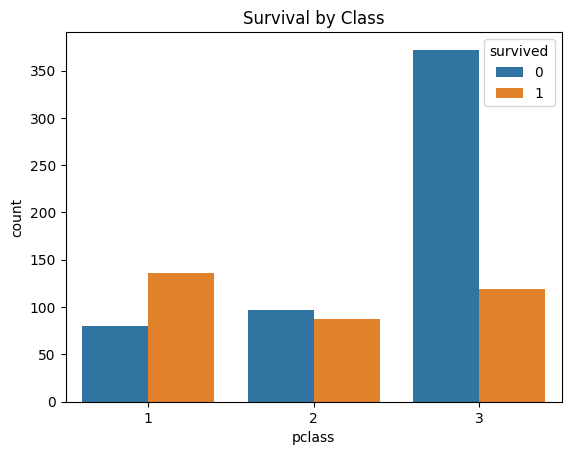

In [10]:
# Survival by class
sns.countplot(x='pclass', hue='survived', data=df)
plt.title('Survival by Class')
plt.show()

## Based on our research so far
- 4 of the features are binary classifiers, 5 including the survived taget classification.
- The lower the class number is the higher the chance the passenger survived.
- Class 3 are the majority population.
- Some classes were made as numerical values where they could have been categorical.

# 2. Data Preprocessing

## Handling the Missing values

In [11]:
# Median imputation for age
df['age'] = df['age'].fillna(df['age'].median())

# Mode filling for embarked
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Drop deck (too many missing values) it would be just fabricating data if we continue to maintain it.
df.drop(columns=['deck'], inplace=True)

### Age, just use median, for embarked use mode, and just drop deck to make sure we are not making our own data and skewing the results.

## Encoding Categorical Features

In [12]:

# Label encode sex (male=1, female=0)
labelEncoder = LabelEncoder()
df['sex'] = labelEncoder.fit_transform(df['sex'])

# One hot encoding for embarked
df = pd.get_dummies(df, columns=['embarked'], drop_first=False)

## Standardize Numerical Features

In [13]:
scaler = StandardScaler()
# We have chosen to use standard scalar because it helps SVM predictors since points are always roughly ditributed around a center
numericColumns = ['age', 'fare', 'sibsp', 'parch']
df[numericColumns] = scaler.fit_transform(df[numericColumns])

## Assert Data is adjusted

In [20]:
# Current data set data after updates
df.info()
# Sample data
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    int64   
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    float64 
 5   parch        891 non-null    float64 
 6   fare         891 non-null    float64 
 7   class        891 non-null    category
 8   who          891 non-null    str     
 9   adult_male   891 non-null    bool    
 10  embark_town  889 non-null    str     
 11  alive        891 non-null    str     
 12  alone        891 non-null    bool    
 13  embarked_C   891 non-null    bool    
 14  embarked_Q   891 non-null    bool    
 15  embarked_S   891 non-null    bool    
dtypes: bool(5), category(1), float64(4), int64(3), str(3)
memory usage: 75.1 KB


,survived,pclass,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone,embarked_C,embarked_Q,embarked_S
0,0,3,1,-0.565736,0.432793,-0.473674,-0.502445,Third,man,True,Southampton,no,False,False,False,True
1,1,1,0,0.663861,0.432793,-0.473674,0.786845,First,woman,False,Cherbourg,yes,False,True,False,False
2,1,3,0,-0.258337,-0.474545,-0.473674,-0.488854,Third,woman,False,Southampton,yes,True,False,False,True
3,1,1,0,0.433312,0.432793,-0.473674,0.420730,First,woman,False,Southampton,yes,False,False,False,True
4,0,3,1,0.433312,-0.474545,-0.473674,-0.486337,Third,man,True,Southampton,no,True,False,False,True


#### As we can see the nulls have been addressed and encodings have been adjusted

# 3. Feature Selection

